<a href="https://colab.research.google.com/github/np03cs4a230349-stack/AI-ML/blob/main/Worksheet6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install if needed
!pip install tensorflow matplotlib pillow scikit-learn

# Imports
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [5]:
train_dir = "/content/drive/MyDrive/AI-ML/FruitinAmazon/train"

# Get class names
class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found!")
else:
    print(f"Found {len(class_names)} classes:", class_names)

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [6]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("Corrupted images found:")
    for img in corrupted_images:
        print(img)
else:
    print("No corrupted images found.")

No corrupted images found.


In [7]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")


Class Distribution:
acai: 15
cupuacu: 15
graviola: 15
guarana: 15
pupunha: 15
tucuma: 15


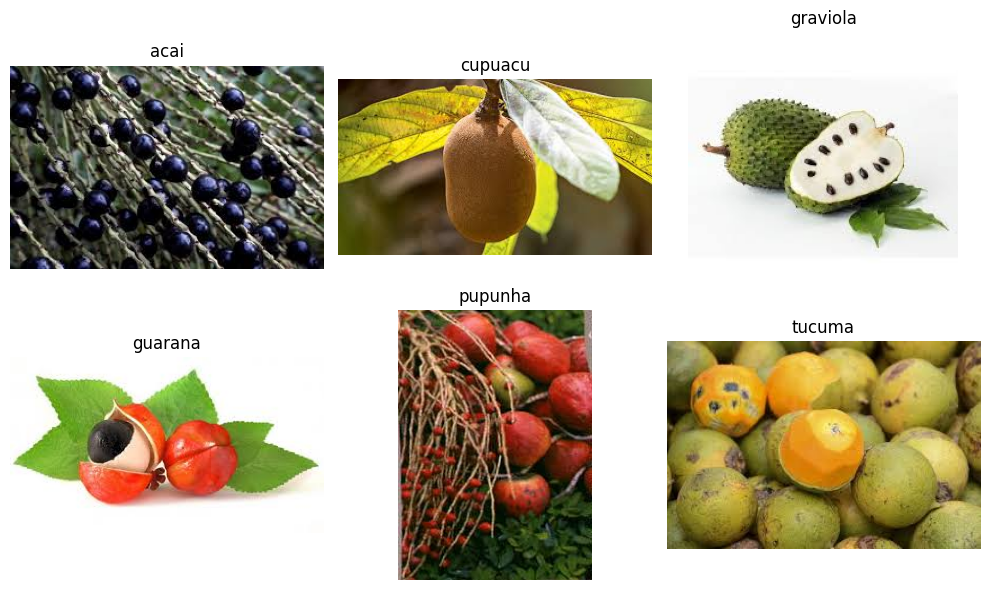

In [8]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    images = [img for img in os.listdir(class_path)
              if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if images:
        img_path = os.path.join(class_path, random.choice(images))
        selected_images.append(img_path)
        selected_labels.append(class_name)

# Plot
cols = 3
rows = (len(selected_images) + 2) // 3

plt.figure(figsize=(10, 6))

for i, img_path in enumerate(selected_images):
    plt.subplot(rows, cols, i+1)
    img = plt.imread(img_path)
    plt.imshow(img)
    plt.title(selected_labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
image_size = (224, 224)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


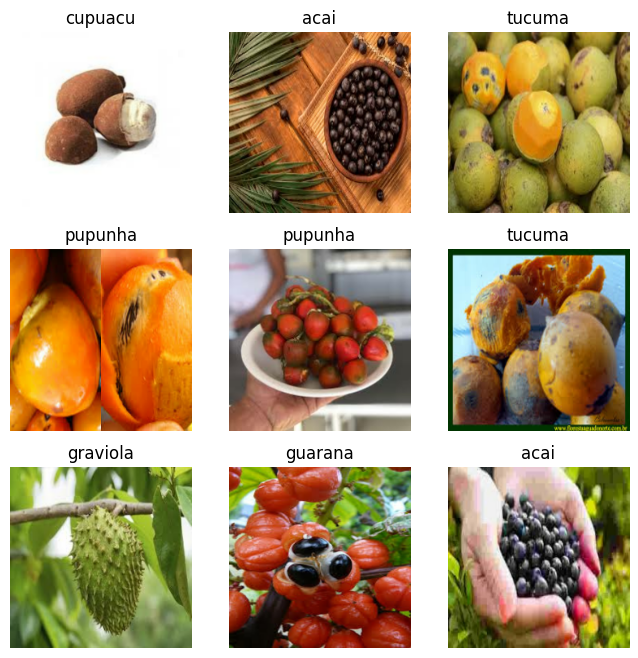

In [10]:
plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [11]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [12]:
model = keras.Sequential([

    layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Dense Layers
    layers.Flatten(),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,54

 Total params: 25,787,078 (98.37 MB)

 Trainable params: 25,786,118 (98.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - accuracy: 0.3194 - loss: 2.3789 - val_accuracy: 0.0556 - val_loss: 3.2201
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.5833 - loss: 1.1052 - val_accuracy: 0.1111 - val_loss: 2.1568
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 5s/step - accuracy: 0.6806 - loss: 0.8895 - val_accuracy: 0.2222 - val_loss: 2.0607
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.7083 - loss: 0.9084 - val_accuracy: 0.1667 - val_loss: 2.0673
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.7500 - loss: 0.6975 - val_accuracy: 0.2222 - val_loss: 2.0378
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.7500 - loss: 0.7836 - val_accuracy: 0.2222 - val_loss: 2.1561
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.7361 - loss: 0.6680 - val_accuracy: 0.1111 - val_loss: 2.3969
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.7917 - loss: 0.5010 - val_accuracy: 0.1111 - val_loss: 2.7979
Epoch 9/

In [15]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1111 - loss: 3.1661
Validation Accuracy: 0.1111111119389534


In [16]:
for images, labels in val_ds.take(1):
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    print("Predicted:", pred_labels[:5])
    print("Actual:   ", labels[:5].numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted: [1 1 1 1 1]
Actual:    [5 2 0 4 3]


In [17]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [18]:
for layer in base_model.layers:
    layer.trainable = False

In [19]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

In [20]:
from tensorflow.keras.models import Model

model_vgg = Model(inputs=base_model.input, outputs=outputs)

In [21]:
model_vgg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history_vgg = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 61s 20s/step - accuracy: 0.1806 - loss: 7.3929 - val_accuracy: 0.2222 - val_loss: 6.3176
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 64s 22s/step - accuracy: 0.5278 - loss: 3.7500 - val_accuracy: 0.3889 - val_loss: 5.5012
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 73s 18s/step - accuracy: 0.7500 - loss: 1.4992 - val_accuracy: 0.5556 - val_loss: 3.0550
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 65s 22s/step - accuracy: 0.9583 - loss: 0.1389 - val_accuracy: 0.5000 - val_loss: 2.4027
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 77s 18s/step - accuracy: 0.9444 - loss: 0.2083 - val_accuracy: 0.5000 - val_loss: 2.6122
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 79s 19s/step - accuracy: 0.9306 - loss: 0.2032 - val_accuracy: 0.6111 - val_loss: 2.4749
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 18s/step - accuracy: 0.9861 - loss: 0.0706 - val_accuracy: 0.6667 - val_loss: 2.2223
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 55s 18s/step - accuracy: 1.0000 - loss: 0.0103 - val_accuracy: 0.6111 - val_loss: 2.0773


In [23]:
loss, acc = model_vgg.evaluate(val_ds)
print("VGG16 Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.6111 - loss: 2.0231
VGG16 Accuracy: 0.6111111044883728


In [24]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_vgg.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step
              precision    recall  f1-score   support

        acai       1.00      1.00      1.00         1
     cupuacu       0.33      0.50      0.40         2
    graviola       0.67      0.67      0.67         3
     guarana       0.80      0.80      0.80         5
     pupunha       0.40      0.50      0.44         4
      tucuma       1.00      0.33      0.50         3

    accuracy                           0.61        18
   macro avg       0.70      0.63      0.64        18
weighted avg       0.68      0.61      0.62        18

